# 220968280 - Anirudh Swaminathan - DSE A2

## week 3 - exercise 2

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.models import Sequential
import cv2
%matplotlib inline

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
def convert_to_grayscale(images):
    grayscale_images = np.zeros((images.shape[0], 32, 32, 1), dtype=np.float32)
    for i in range(images.shape[0]):
        gray_image = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY)
        grayscale_images[i, :, :, 0] = gray_image
    return grayscale_images

X_train_grey = convert_to_grayscale(X_train)
X_test_grey = convert_to_grayscale(X_test)

### Compute and display the number of classes.

In [5]:
num_classes = max(y_train) + 1
print(f'number of classes: {num_classes}')

number of classes: [10]


### Compute and display the dimensions of each image.

In [6]:
num_features = len(X_train[0]) * len(X_train[0][0])
print(f'dimensions of each image: {len(X_train[0])} x {len(X_train[0][0])}')

dimensions of each image: 32 x 32


### Display one image from each class.

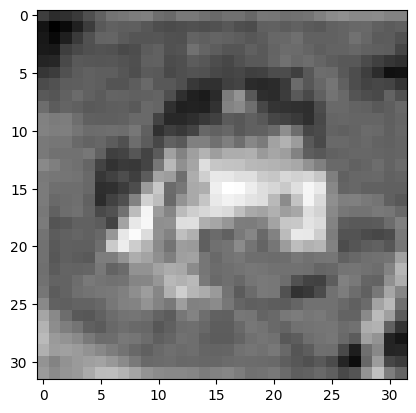

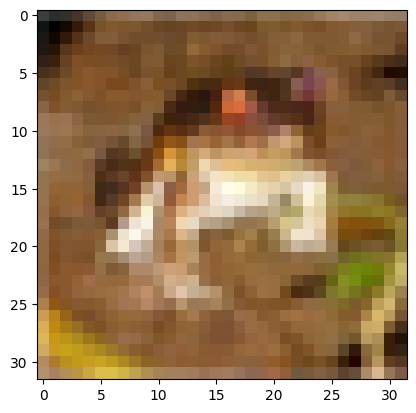

In [7]:
plt.imshow(X_train_grey[0], cmap='gray')
plt.show()
plt.imshow(X_train[0])

### Perform normalization.

In [8]:
X_train_grey = X_train_grey/255.0
X_test_grey = X_test_grey/255.0

### Performing experiments on Fully Connected Neural Networks (FCNN)

In [9]:
FCNN = Sequential([
    Flatten(input_shape=[32,32]),
    Dense(300, activation='relu'),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])
FCNN.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 1024)              0         
                                                                 
 dense (Dense)               (None, 300)               307500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 338610 (1.29 MB)
Trainable params: 338610 (1.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
FCNN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
h = FCNN.fit(X_train_grey, y_train, epochs=20, batch_size=128, validation_split=0.15)

Epoch 1/20
333/333 [==============================] - 3s 8ms/step - loss: 2.0783 - Accuracy: 0.2437 - val_loss: 2.0391 - val_Accuracy: 0.2732
Epoch 2/20
333/333 [==============================] - 2s 7ms/step - loss: 1.9365 - Accuracy: 0.3062 - val_loss: 1.9340 - val_Accuracy: 0.2916
Epoch 3/20
333/333 [==============================] - 2s 7ms/step - loss: 1.8708 - Accuracy: 0.3335 - val_loss: 1.8928 - val_Accuracy: 0.3061
Epoch 4/20
333/333 [==============================] - 2s 7ms/step - loss: 1.8229 - Accuracy: 0.3505 - val_loss: 1.8828 - val_Accuracy: 0.3212
Epoch 5/20
333/333 [==============================] - 3s 8ms/step - loss: 1.7884 - Accuracy: 0.3637 - val_loss: 1.8658 - val_Accuracy: 0.3381
Epoch 6/20
333/333 [==============================] - 3s 8ms/step - loss: 1.7630 - Accuracy: 0.3716 - val_loss: 1.8700 - val_Accuracy: 0.3427
Epoch 7/20
333/333 [==============================] - 2s 7ms/step - loss: 1.7302 - Accuracy: 0.3861 - val_loss: 1.7711 - val_Accuracy: 0.3647
Epoch 

In [11]:
FCNN.evaluate(X_test_grey, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 1.6974 - Accuracy: 0.4054


[1.6974143981933594, 0.40540000796318054]

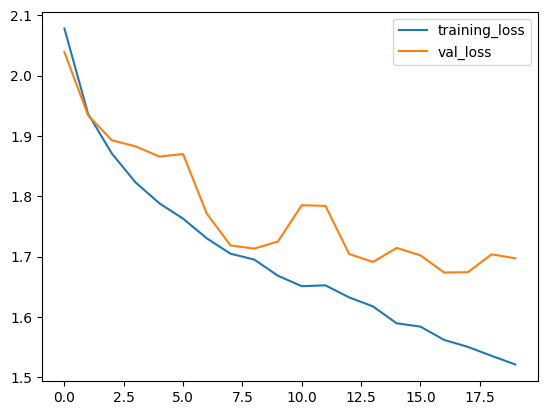

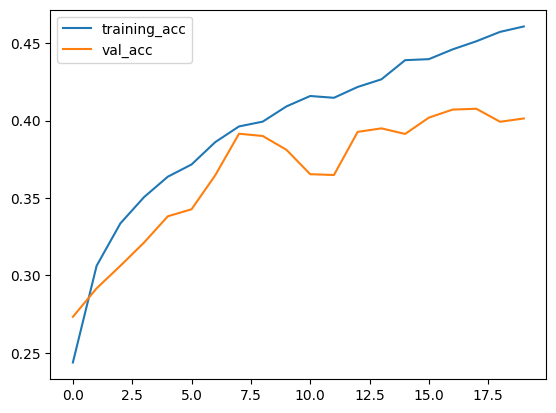

In [12]:
plt.plot(h.history['loss'], label='training_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.plot(h.history['Accuracy'], label='training_acc')
plt.plot(h.history['val_Accuracy'], label='val_acc')
plt.legend()
plt.show()

### Performing experiments on a Convolutional Neural Networks (CNNs):

In [13]:
CNN1 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(kernel_size=(5, 5), filters=32, strides=1, padding='valid', activation='relu'),
    MaxPool2D(strides=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])
CNN1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        2432      
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 flatten_1 (Flatten)         (None, 6272)              0         
                                                                 
 dense_3 (Dense)             (None, 100)               627300    
                                                                 
 dense_4 (Dense)             (None, 10)                1010      
                                                                 
Total params: 630742 (2.41 MB)
Trainable params: 630742 (2.41 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

In [14]:
CNN1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
h = CNN1.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.15)

Epoch 1/20
333/333 [==============================] - 13s 39ms/step - loss: 4.9295 - Accuracy: 0.2435 - val_loss: 1.9643 - val_Accuracy: 0.2929
Epoch 2/20
333/333 [==============================] - 13s 39ms/step - loss: 1.7396 - Accuracy: 0.3783 - val_loss: 1.7732 - val_Accuracy: 0.3905
Epoch 3/20
333/333 [==============================] - 14s 41ms/step - loss: 1.5203 - Accuracy: 0.4550 - val_loss: 1.6399 - val_Accuracy: 0.4364
Epoch 4/20
333/333 [==============================] - 14s 41ms/step - loss: 1.3650 - Accuracy: 0.5129 - val_loss: 1.6193 - val_Accuracy: 0.4477
Epoch 5/20
333/333 [==============================] - 13s 38ms/step - loss: 1.2064 - Accuracy: 0.5711 - val_loss: 1.6832 - val_Accuracy: 0.4497
Epoch 6/20
333/333 [==============================] - 14s 41ms/step - loss: 1.0704 - Accuracy: 0.6199 - val_loss: 1.8857 - val_Accuracy: 0.3972
Epoch 7/20
333/333 [==============================] - 14s 41ms/step - loss: 1.0016 - Accuracy: 0.6476 - val_loss: 1.8442 - val_Accuracy:

In [15]:
CNN1.evaluate(X_test, y_test)

313/313 [==============================] - 2s 6ms/step - loss: 4.4324 - Accuracy: 0.4357


[4.432424068450928, 0.435699999332428]

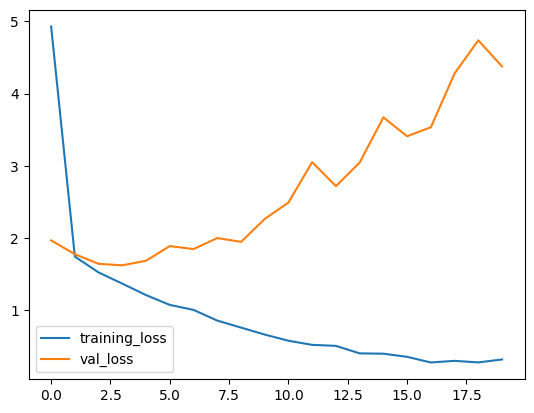

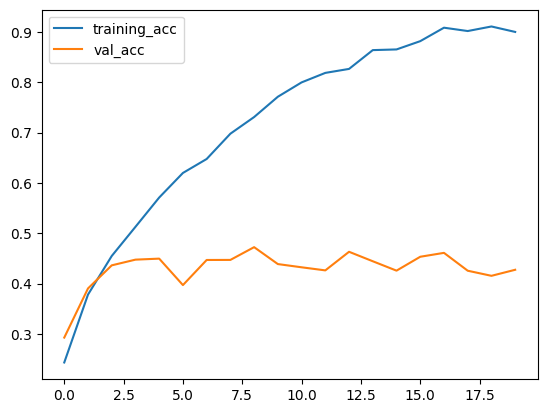

In [16]:
plt.plot(h.history['loss'], label='training_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.plot(h.history['Accuracy'], label='training_acc')
plt.plot(h.history['val_Accuracy'], label='val_acc')
plt.legend()
plt.show()

In [17]:
CNN2 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(kernel_size=3, filters=32, strides=1, padding='valid', activation='relu'),
    Conv2D(kernel_size=3, filters=32, strides=1, padding='valid', activation='relu'),
    MaxPool2D(strides=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])
CNN2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 6272)              0         
                                                                 
 dense_5 (Dense)             (None, 100)               627300    
                                                                 
 dense_6 (Dense)             (None, 10)                1010      
                                                      

In [18]:
CNN2.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
h = CNN2.fit(X_train, y_train, epochs=15, batch_size=128, validation_split=0.15)

Epoch 1/15
333/333 [==============================] - 27s 79ms/step - loss: 2.9543 - Accuracy: 0.3317 - val_loss: 1.6660 - val_Accuracy: 0.4044
Epoch 2/15
333/333 [==============================] - 28s 83ms/step - loss: 1.4171 - Accuracy: 0.4985 - val_loss: 1.4499 - val_Accuracy: 0.4889
Epoch 3/15
333/333 [==============================] - 28s 85ms/step - loss: 1.1798 - Accuracy: 0.5838 - val_loss: 1.6717 - val_Accuracy: 0.4764
Epoch 4/15
333/333 [==============================] - 30s 90ms/step - loss: 1.0960 - Accuracy: 0.6145 - val_loss: 1.3465 - val_Accuracy: 0.5431
Epoch 5/15
333/333 [==============================] - 30s 90ms/step - loss: 0.8897 - Accuracy: 0.6889 - val_loss: 1.3240 - val_Accuracy: 0.5636
Epoch 6/15
333/333 [==============================] - 30s 90ms/step - loss: 0.7057 - Accuracy: 0.7520 - val_loss: 1.4536 - val_Accuracy: 0.5541
Epoch 7/15
333/333 [==============================] - 30s 91ms/step - loss: 0.5409 - Accuracy: 0.8123 - val_loss: 1.7032 - val_Accuracy:

In [19]:
CNN2.evaluate(X_test, y_test)

313/313 [==============================] - 3s 10ms/step - loss: 3.3891 - Accuracy: 0.5535


[3.389080047607422, 0.5534999966621399]

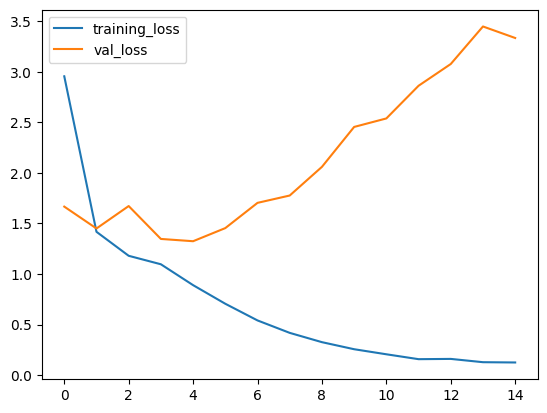

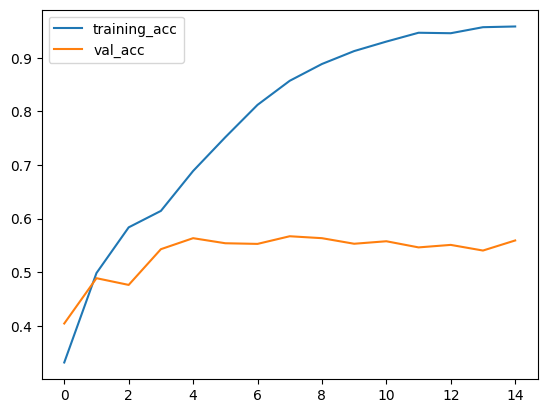

In [20]:
plt.plot(h.history['loss'], label='training_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.plot(h.history['Accuracy'], label='training_acc')
plt.plot(h.history['val_Accuracy'], label='val_acc')
plt.legend()
plt.show()

CNN2 has 12% higher accuracy than CNN1. Both models are overfitting a lot.

FCNN has an accuracy of 40.54%. CNN1 has an accuracy of 43.57%. CNN2 has an accuracy of 55.35%. CNN has outperformed FCNN in for this situation. Should be noted that both the CNN models are overfitting a lot more than the FCNN model.

FCNN - 338610 parameters  
CNN1 - 630742 parameters  
CNN2 - 638454 parameters

Most amount of parameters were added from the initial Dense layer in each of the models.